<h1><center>LSTM-based MODELS</center></h1>

## I. LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import os
import datetime
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import RepeatVector
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
tf.random.set_seed(8) # fix random seed for reproducibility

Num GPUs Available:  0


## II. HYPERPARAMETERS

In [2]:
# Global param
Y_COL = 0 # the column index (0-based) in the dataset corresponding to the target variable (output)
FEATURE_NUMBER = 1
MODEL_LOCATION = "./Saved Model/New Cleaned"
# Hyperparameter
TRAIN_TEST_RATIO = 0.8
TIME_STEP = 10
MODEL_TYPE = "LSTM"
# MODEL_TYPE = "CNN_LSTM_DNN"
EPOCH_SIZE = 1000
BATCH_SIZE = 5
MODEL_JSON = {}
MIN_DELTA = 0.0001
PATIENCE = 15
# X = [41,2,1,1,16,1,1,1,864] # SSO_CNN.txt
CNN_LSTM = [2,2,1,248,257,51,8]
EARLY_STOPPING = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    min_delta=MIN_DELTA,
    patience=PATIENCE,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)


def to_string():
    print_list = [
        f"Time step: {TIME_STEP}",
        f"Ratio: {TRAIN_TEST_RATIO}",
        f"Model type: {MODEL_TYPE}",
        f"Epoch size: {EPOCH_SIZE}",
        f"Batch size: {BATCH_SIZE}",
        f"Early stop patience: {PATIENCE}, min delta: {MIN_DELTA}",
        f"Model json: {MODEL_JSON}",
    ]
    return "\n".join(print_list)

## III. DATA PRE-PROCESSING

### 3.1. Extract & Clean Data

In [3]:
# Load Data into Dataframe
# Data of year 2021
df1 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 1", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 2", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL')
df3 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 3", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df4 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 4", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df5 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 5", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df6 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 6", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df7 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 7", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df8 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 8", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df9 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 9", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df10 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 10", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df11 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 11", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df12 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 12", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')


# Merge many columns of 1 df into one column of that df
df1_melted = pd.melt(df1)
df2_melted = pd.melt(df2)
df3_melted = pd.melt(df3)
df4_melted = pd.melt(df4)
df5_melted = pd.melt(df5)
df6_melted = pd.melt(df6)
df7_melted = pd.melt(df7)
df8_melted = pd.melt(df8)
df9_melted = pd.melt(df9)
df10_melted = pd.melt(df10)
df11_melted = pd.melt(df11)
df12_melted = pd.melt(df12)

# Data of year 2022
df2_1 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 1", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2_2 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 2", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL')
df2_3 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 3", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2_4 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 4", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df2_5 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 5", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_6 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 6", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
df2_7 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 7", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_8 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 8", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_9 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 9", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
df2_10 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 10", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
df2_11 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 11", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
df2_12 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 12", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')


# Merge many columns of 1 df into one column of that df
df2_1_melted = pd.melt(df2_1)
df2_2_melted = pd.melt(df2_2)
df2_3_melted = pd.melt(df2_3)
df2_4_melted = pd.melt(df2_4)
df2_5_melted = pd.melt(df2_5)
df2_6_melted = pd.melt(df2_6)
df2_7_melted = pd.melt(df2_7)
df2_8_melted = pd.melt(df2_8)
df2_9_melted = pd.melt(df2_9)
df2_10_melted = pd.melt(df2_10)
df2_11_melted = pd.melt(df2_11)
df2_12_melted = pd.melt(df2_12)

print(df2_12_melted) #check

     variable  value
0           7    3.3
1           7    4.8
2           7    5.7
3           7   12.2
4           7   10.1
..        ...    ...
646       217   12.8
647       217    4.2
648       217    4.2
649       217    2.4
650       217    1.6

[651 rows x 2 columns]


In [4]:
# Concatenate all dfs which have been already reshaped above into 1 single df
# Select only the second column from each DataFrame
df1_power_value = df1_melted.iloc[:, 1]
df2_power_value = df2_melted.iloc[:, 1]
df3_power_value = df3_melted.iloc[:, 1]
df4_power_value = df4_melted.iloc[:, 1]
df5_power_value = df5_melted.iloc[:, 1]
df6_power_value = df6_melted.iloc[:, 1]
df7_power_value = df7_melted.iloc[:, 1]
df8_power_value = df8_melted.iloc[:, 1]
df9_power_value = df9_melted.iloc[:, 1]
df10_power_value = df10_melted.iloc[:, 1]
df11_power_value = df11_melted.iloc[:, 1]
df12_power_value = df12_melted.iloc[:, 1]

df2_1_power_value = df2_1_melted.iloc[:, 1]
df2_2_power_value = df2_2_melted.iloc[:, 1]
df2_3_power_value = df2_3_melted.iloc[:, 1]
df2_4_power_value = df2_4_melted.iloc[:, 1]
df2_5_power_value = df2_5_melted.iloc[:, 1]
df2_6_power_value = df2_6_melted.iloc[:, 1]
df2_7_power_value = df2_7_melted.iloc[:, 1]
df2_8_power_value = df2_8_melted.iloc[:, 1]
df2_9_power_value = df2_9_melted.iloc[:, 1]
df2_10_power_value = df2_10_melted.iloc[:, 1]
df2_11_power_value = df2_11_melted.iloc[:, 1]
df2_12_power_value = df2_12_melted.iloc[:, 1]



# Concatenate the selected columns
concatenated_df1 = pd.concat([df1_power_value, df2_power_value, df3_power_value, df4_power_value, df5_power_value, df6_power_value, df7_power_value, df8_power_value, df9_power_value, df10_power_value, df11_power_value, df12_power_value])
concatenated_df2 = pd.concat([df2_1_power_value, df2_2_power_value, df2_3_power_value, df2_4_power_value, df2_5_power_value, df2_6_power_value, df2_7_power_value, df2_8_power_value, df2_9_power_value, df2_10_power_value, df2_11_power_value, df2_12_power_value])
concatenated_df = pd.concat([concatenated_df1, concatenated_df2])

# Convert the concatenated column into a 1-dimensional array as the result of concatenation will already be a pandas Series, which behaves similarly to a 1-dimensional array
concatenated_df_arr = concatenated_df.values.ravel()

print(concatenated_df_arr)
print(len(concatenated_df_arr))

# Specify the path where want to save the Excel file
output_path = "./Data/output_concatenated_df.xlsx"

# Export the DataFrame to Excel
concatenated_df.to_excel(output_path, index=False)  # Set index=False to exclude row numbers

[ 4.6 10.  17.5 ...  4.2  2.4  1.6]
15330


### 3.2. Preprocessing (PDF)

mean 17.978336594911934
std 10.63311175506827
Reject the null hypothesis: Data does not follow a normal distribution.
counts [0.0269832  0.03197497 0.02693719 0.02850143 0.02679917 0.03031871
 0.0295826  0.02907652 0.02679917 0.02291156 0.02270453 0.02206043
 0.01817283 0.00982253]
counts_number [1173 1390 1171 1239 1165 1318 1286 1264 1165  996  987  959  790  427]
bin_dataset [ 0.1         2.93571429  5.77142857  8.60714286 11.44285714 14.27857143
 17.11428571 19.95       22.78571429 25.62142857 28.45714286 31.29285714
 34.12857143 36.96428571 39.8       ]


c:\Users\Nhan Duong\anaconda3\envs\new_kera_env\lib\site-packages\scipy\stats\_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


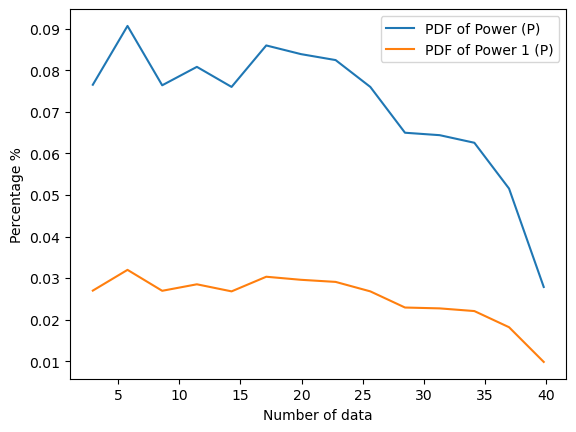

In [5]:
# Preprocessing
dataset = concatenated_df.values.astype("float64")
new_dataset = np.array(np.zeros((1, FEATURE_NUMBER)))
j = 0
mean = np.mean(dataset)
print("mean", mean)
standard_deviation = np.std(dataset)
print("std", standard_deviation)

# Shapiro-Wilk test to determine whether a sample comes from a normal distribution
from scipy.stats import shapiro
statistic, p_value = shapiro(dataset)
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Data does not follow a normal distribution.")
else:
    print("Fail to reject the null hypothesis: Data may come from a normal distribution.")

# Check PDF of data
bins_size = int(1 + 3.3 * np.log10(len(dataset)))
counts, bin_dataset = np.histogram(dataset, bins=bins_size, density=True)
counts_number, bin_dataset = np.histogram(dataset, bins=bins_size)
rel_freq = counts_number / len(dataset)
print("counts", counts)
print("counts_number", counts_number)
print("bin_dataset", bin_dataset)
plt.clf()
plt.plot(bin_dataset[1:], rel_freq, label="PDF of Power (P)")
plt.plot(bin_dataset[1:], counts, label="PDF of Power 1 (P)")
plt.xlabel("Number of data")
plt.ylabel("Percentage %")
plt.legend()
plt.show()

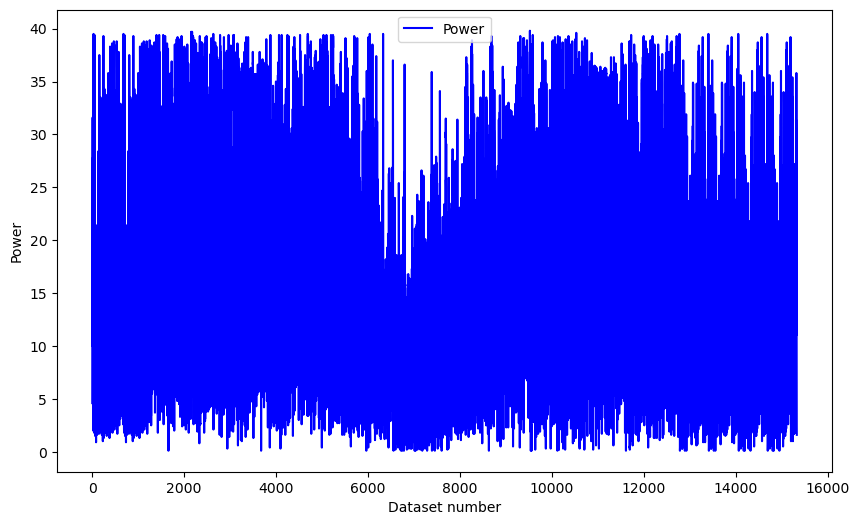

In [6]:
# Plot data (for 1 feature only)
plt.figure(figsize=(10,6))
plt.plot(dataset, color="blue", label="Power")
plt.xlabel("Dataset number")
plt.ylabel("Power")
leg = plt.legend()

# Other features
# plt.twinx()
# plt.ylabel("Temperature")
# plt.plot(dataset[:,0], color="red", label="Temperature")
# leg = plt.legend()
# plt.rcParams.update({'font.size': 10})

plt.show()

### 3.3. Data Split & Normalization

* Split data before normalization to ensure the accuracy
* The MinMaxScaler is used to scale the data to a range between 0 and 1 so that all features are on the same scale. This is important because the LSTM model used for time series prediction is sensitive to the scale of the input data.

In [8]:
# Split into train and test sets
train_size = int(len(dataset) * TRAIN_TEST_RATIO)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size], dataset[train_size:len(dataset)]
print(f"Total : {len(dataset)}, Train: {len(train)}, Test: {len(test)}")
print(train.ndim, test.ndim)

Total : 15330, Train: 12264, Test: 3066
1 1


In [9]:
# Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back)]
		dataX.append(a)
		dataY.append(dataset[i + look_back])
	return np.array(dataX), np.array(dataY)

In [10]:
# Create scaler to normalize
scaler = MinMaxScaler(feature_range=(0, 1))
# Normalize x
train_x = scaler.fit_transform(train.reshape(-1, 1))
test_x = scaler.transform(test.reshape(-1, 1))
# Reshape into X=t and Y=t+TIME_STEP
train_x, _ = create_dataset(train_x, TIME_STEP)
test_x, _ = create_dataset(test_x, TIME_STEP)
_ , train_y = create_dataset(train, TIME_STEP)
_ , test_y = create_dataset(test, TIME_STEP)
# Normalize y 
train_y = scaler.fit_transform(train_y.reshape(-1,1))
test_y = scaler.transform(test_y.reshape(-1,1))

Reject the null hypothesis: Data does not follow a normal distribution.
counts [0.92091733 1.18382437 1.02729128 1.10898555 1.02637721 1.16828532
 1.14794744 1.18142496 1.12738105 0.95359504 0.97061944 0.96079328
 0.81580021 0.40675753]
counts_number [ 8060 10361  8991  9706  8983 10225 10047 10340  9867  8346  8495  8409
  7140  3560]
bin_dataset [0.         0.07142857 0.14285714 0.21428571 0.28571429 0.35714286
 0.42857143 0.5        0.57142857 0.64285714 0.71428571 0.78571429
 0.85714286 0.92857143 1.        ]


c:\Users\Nhan Duong\anaconda3\envs\new_kera_env\lib\site-packages\scipy\stats\_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


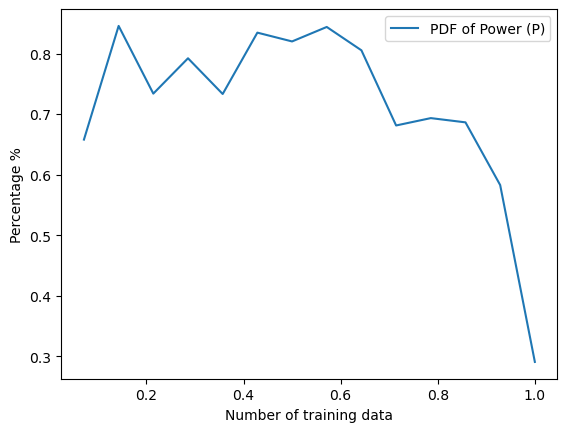

In [11]:
# Shapiro-Wilk test to determine whether a sample comes from a normal distribution
from scipy.stats import shapiro
statistic, p_value = shapiro(train_x)
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Data does not follow a normal distribution.")
else:
    print("Fail to reject the null hypothesis: Data may come from a normal distribution.")

# Check PDF of data after normalization
bins_size = int(1 + 3.3 * np.log10(len(train_x)))
counts, bin_train_x = np.histogram(train_x, bins=bins_size, density=True)
counts_number, bin_train_x = np.histogram(train_x, bins=bins_size)
rel_freq = counts_number / len(train_x)
print("counts", counts)
print("counts_number", counts_number)
print("bin_dataset", bin_train_x)
plt.clf()
plt.plot(bin_train_x[1:], rel_freq, label="PDF of Power (P)")
plt.xlabel("Number of training data")
plt.ylabel("Percentage %")
plt.legend()
plt.show()

In [12]:
# reshape input to be [samples, time steps, features]
train_x = np.reshape(train_x, (train_x.shape[0], TIME_STEP, FEATURE_NUMBER))
test_x = np.reshape(test_x, (test_x.shape[0], TIME_STEP, FEATURE_NUMBER))

## IV. TRAINING MODELS

Depending on the model type input in the Hyperparameters section at the beginning, it will add different layers for different model types.

In [13]:
# create and fit the network
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
model = Sequential()
if MODEL_TYPE == "CNN": # 
    model.add(
        Conv1D(32, (2), activation="relu", input_shape=(TIME_STEP, FEATURE_NUMBER))
    )
    model.add(Conv1D(16, (2), activation="relu"))
    model.add(Conv1D(8, (1), activation="relu"))
    model.add(MaxPooling1D((2)))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM":
    # Adds an LSTM layer with 32 units to the model
    model.add(LSTM(32, input_shape=(TIME_STEP, 1), return_sequences=True))
    # Adds another LSTM layer with 32 units to the model
    model.add(LSTM(32, input_shape=(TIME_STEP, 1)))
    # Adds a dense layer with one unit to the model
    model.add(Dense(1)) 
elif MODEL_TYPE == "CNN_LSTM":
    model.add(
        Conv1D(6, (2), activation="relu", input_shape=(TIME_STEP, FEATURE_NUMBER))
    )
    model.add(LSTM(300, "relu", input_shape=(TIME_STEP, FEATURE_NUMBER)))
    model.add(Dense(1))
elif MODEL_TYPE == "CNN_LSTM_DNN":
    model.add(
        Conv1D(8, (2), activation="relu", input_shape=(TIME_STEP, FEATURE_NUMBER))
    )
    model.add(LSTM(32, "relu", return_sequences=True))
    model.add(LSTM(32, "relu"))
    model.add(Dense(16))
    model.add(Dense(8))
    model.add(Dense(1))
model.summary()
MODEL_JSON = model.to_json()
model.compile(loss="mse", optimizer="adam", metrics=["mse", "mae", "mape"])
model.fit(
    train_x,
    train_y,
    epochs=EPOCH_SIZE,
    batch_size=BATCH_SIZE,
    verbose=2,
    callbacks=[EARLY_STOPPING, tensorboard_callback],
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 32)            4352      
                                                                 
 lstm_1 (LSTM)               (None, 32)                8320      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 12,705
Trainable params: 12,705
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
2451/2451 - 48s - loss: 0.0279 - mse: 0.0279 - mae: 0.1291 - mape: 294759.0938 - 48s/epoch - 20ms/step
Epoch 2/1000
2451/2451 - 50s - loss: 0.0210 - mse: 0.0210 - mae: 0.1080 - mape: 189311.1406 - 50s/epoch - 20ms/step
Epoch 3/1000
2451/2451 - 43s - loss: 0.0204 - mse: 0.0204 - mae: 0.1059 - mape: 1375

In [14]:
# Save model
version = 0
if not os.path.exists(MODEL_LOCATION):
    os.makedirs(MODEL_LOCATION)
for dir in os.scandir(f"{MODEL_LOCATION}/"):
    if dir.is_dir():
        version = int(dir.name) if int(dir.name) > version else version
version += 1
model.save(f"{MODEL_LOCATION}/{version}")

INFO:tensorflow:Assets written to: ./Saved Model/New Cleaned/2\assets


INFO:tensorflow:Assets written to: ./Saved Model/New Cleaned/2\assets


## V. PREDICTION

1. **RMSE (Root Mean Squared Error):** 
    * Lower RMSE values are generally better. A lower RMSE indicates that your model's predictions are closer to the true values.
    * However, whether a particular RMSE is good or not depends on the scale of your data. 
2. **RMSPE (Root Mean Squared Percentage Error):** usually expressed as a percentage
3. **MAE (Mean Absolute Error):** lower MAE values are better. MAE measures the average magnitude of errors, and a lower MAE indicates that the model's predictions are closer to the true values.
4. **MAPE (Mean Absolute Percentage Error):** the average percentage difference between predictions and their intended targets in the dataset. *The lower the value for MAPE, the better the machine learning model* is at predicting values.

### 5.1. Normal Prediction

[0.03941349312663078, 0.03941349312663078, 0.15029920637607574, 828126.0]
96/96 [==============================] - 1s 7ms/step
Train MSE Score: 4.269482452195041 MSE
Test MSE Score: 62.119222560016858 MSE
Train MAE Score: 1.513090289245184 MAE
Test MAE Score: 5.966877724315769 MAE
Train MAPE Score: 0.2149 MAPE
Test MAPE Score: 1.2327 MAPE
Train RMSE Score: 2.066272598713693 RMSE
Test RMSE Score: 7.881574878158353 RMSE
Train RMSPE: 1.1948 RMSPE
Test RMSPE: 5.7999 RMSPE


<Figure size 640x480 with 0 Axes>

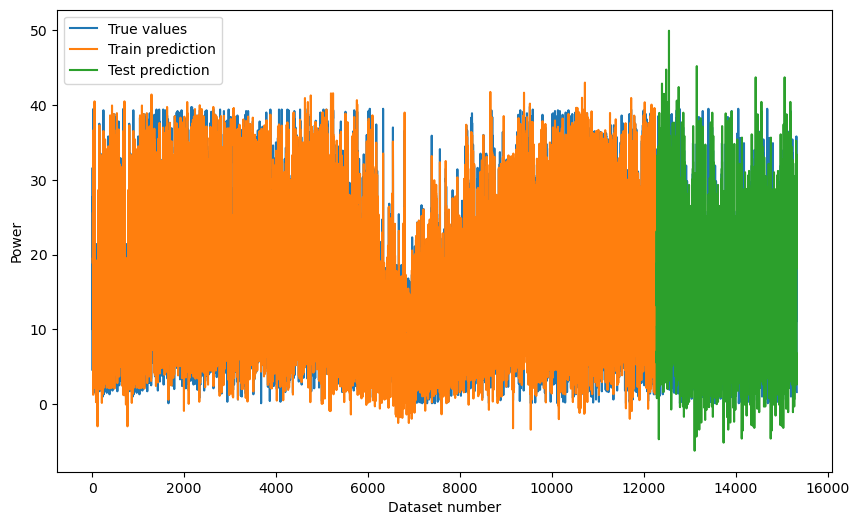

In [15]:
# predictions
score = model.evaluate(test_x, test_y,batch_size=20, verbose=0)  # return MAPE
print(score)

# predict result of train and test for evaluation
train_predict = model.predict(train_x)
test_predict = model.predict(test_x)
# invert predictions to get value before normalize
train_predict = scaler.inverse_transform(train_predict)
train_true = scaler.inverse_transform(train_y).reshape(1, -1)
test_predict = scaler.inverse_transform(test_predict)
test_true = scaler.inverse_transform(test_y).reshape(1, -1)

# calculate mean absolute error (MAE)
train_mae = mean_absolute_error(train_true[0], train_predict[:, 0])
test_mae = mean_absolute_error(test_true[0], test_predict[:, 0])
# calculate mean absolute percentage error (MAPE)
train_mape = mean_absolute_percentage_error(train_true[0], train_predict[:, 0])
test_mape = mean_absolute_percentage_error(test_true[0], test_predict[:, 0])
# calculate mean squared error (MSE)
train_mse = mean_squared_error(train_true[0], train_predict[:, 0])
test_mse = mean_squared_error(test_true[0], test_predict[:, 0])
# calculate root mean squared error (RMSE)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
# calculate root mean squared percentage error (RMSPE)
train_rmspe = np.sqrt(
    np.mean(
        np.square(((train_true[0] - train_predict[:, 0]) / train_true[0])),
        axis=0,
    )
)
test_rmspe = np.sqrt(
    np.mean(
        np.square(((test_true[0] - test_predict[:, 0]) / test_true[0])),
        axis=0,
    )
)

train_mse_output = "Train MSE Score: %.15f MSE" % train_mse
test_mse_output = "Test MSE Score: %.15f MSE" % test_mse
train_mae_output = "Train MAE Score: %.15f MAE" % train_mae
test_mae_output = "Test MAE Score: %.15f MAE" % test_mae
train_mape_output = "Train MAPE Score: %.4f MAPE" % train_mape
test_mape_output = "Test MAPE Score: %.4f MAPE" % test_mape
train_rmse_output = "Train RMSE Score: %.15f RMSE" % train_rmse
test_rmse_output = "Test RMSE Score: %.15f RMSE" % test_rmse
train_rmspe_output = "Train RMSPE: %.4f RMSPE" % train_rmspe
test_rmspe_output = "Test RMSPE: %.4f RMSPE" % test_rmspe
print(train_mse_output)
print(test_mse_output)
print(train_mae_output)
print(test_mae_output)
print(train_mape_output)
print(test_mape_output)
print(train_rmse_output)
print(test_rmse_output)
print(train_rmspe_output)
print(test_rmspe_output)

rmse_file = open(f"./{MODEL_LOCATION}/{version}/info.md", "w")
rmse_file.write(
    train_mse_output
    + "\n"
    + test_mse_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + train_rmse_output
    + "\n"
    + test_rmse_output
    + "\n"
    + train_rmspe_output
    + "\n"
    + test_rmspe_output
)
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset).reshape(-1, 1)
trainPredictPlot[:] = np.nan
trainPredictPlot[TIME_STEP : len(train_predict) + TIME_STEP] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset).reshape(-1, 1)
testPredictPlot[:] = np.nan
testPredictPlot[
    len(train_predict) + (TIME_STEP * 2) + 1 : len(dataset) - 1
] = test_predict

true_values = (dataset).reshape(-1, 1)
# plot baseline and predictions
plt.clf()
plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 10})
plt.xlabel("Dataset number")
plt.ylabel("Power")
plt.plot(true_values, label="True values")
# plt.plot(test_true.reshape(-1,1), label="Test true")
plt.plot(trainPredictPlot, label="Train prediction")
plt.plot(testPredictPlot, label="Test prediction")
leg = plt.legend()

plt.savefig(f"{MODEL_LOCATION}/{version}/predict_normal.png")
plt.show()

### 5.2. Cumulative Prediction

In [16]:
# Getting prediction for cumulative result

train_predict = model.predict(train_x)
test_predict = model.predict(test_x)
# invert predictions
train_predict = scaler.inverse_transform(train_predict)
train_true = scaler.inverse_transform(train_y).reshape(1, -1)
test_predict = scaler.inverse_transform(test_predict)
test_true = scaler.inverse_transform(test_y).reshape(1, -1)

# get cumulative train and test predictions
true_values = np.cumsum((dataset).reshape(-1,1))
train_true = np.cumsum(train_true).reshape(1, -1)
test_true = true_values[-len(test_true[0]):].reshape(1,-1)

train_predict = np.cumsum(train_predict).reshape(-1, 1)
test_predict = np.cumsum(np.append(test_true[0, 0], test_predict))[1:].reshape(-1, 1)

# calculate mean absolute error (MAE)
train_mae = mean_absolute_error(train_true[0], train_predict[:, 0])
test_mae = mean_absolute_error(test_true[0], test_predict[:, 0])
# calculate mean absolute percentage error (MAPE)
train_mape = mean_absolute_percentage_error(train_true[0], train_predict[:, 0])
test_mape = mean_absolute_percentage_error(test_true[0], test_predict[:, 0])
# calculate mean squared error (MSE)
train_mse = mean_squared_error(train_true[0], train_predict[:, 0])
test_mse = mean_squared_error(test_true[0], test_predict[:, 0])
# calculate root mean squared error (RMSE)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
# calculate root mean squared percentage error (RMSPE)
train_rmspe = np.sqrt(
    np.mean(
        np.square(((train_true[0] - train_predict[:, 0]) / train_true[0])),
        axis=0,
    )
)
test_rmspe = np.sqrt(
    np.mean(
        np.square(((test_true[0] - test_predict[:, 0]) / test_true[0])),
        axis=0,
    )
)

train_mse_output = "Train MSE Score: %.15f MSE" % train_mse
test_mse_output = "Test MSE Score: %.15f MSE" % test_mse
train_mae_output = "Train MAE Score: %.15f MAE" % train_mae
test_mae_output = "Test MAE Score: %.15f MAE" % test_mae
train_mape_output = "Train MAPE Score: %.4f MAPE" % train_mape
test_mape_output = "Test MAPE Score: %.4f MAPE" % test_mape
train_rmse_output = "Train RMSE Score: %.15f RMSE" % train_rmse
test_rmse_output = "Test RMSE Score: %.15f RMSE" % test_rmse
train_rmspe_output = "Train RMSPE: %.4f RMSPE" % train_rmspe
test_rmspe_output = "Test RMSPE: %.4f RMSPE" % test_rmspe
print(train_mse_output)
print(test_mse_output)
print(train_mae_output)
print(test_mae_output)
print(train_mape_output)
print(test_mape_output)
print(train_rmse_output)
print(test_rmse_output)
print(train_rmspe_output)
print(test_rmspe_output)

rmse_file = open(f"./{MODEL_LOCATION}/{version}/info.md", "a")
rmse_file.write(
    "\n\nCumulative:\n"
    + train_mse_output
    + "\n"
    + test_mse_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + train_rmse_output
    + "\n"
    + test_rmse_output
    + "\n"
    + train_rmspe_output
    + "\n"
    + test_rmspe_output
    + "\n\n"
    + to_string()
)
rmse_file.close()

96/96 [==============================] - 1s 8ms/step
Train MSE Score: 188157.556914633139968 MSE
Test MSE Score: 1774974.671782388817519 MSE
Train MAE Score: 388.350999771208421 MAE
Test MAE Score: 1043.816817535688415 MAE
Train MAPE Score: 0.0036 MAPE
Test MAPE Score: 0.0040 MAPE
Train RMSE Score: 433.771318686048119 RMSE
Test RMSE Score: 1332.281753902825585 RMSE
Train RMSPE: 0.0042 RMSPE
Test RMSPE: 0.0050 RMSPE


(15330,)
(15330, 1)


<Figure size 640x480 with 0 Axes>

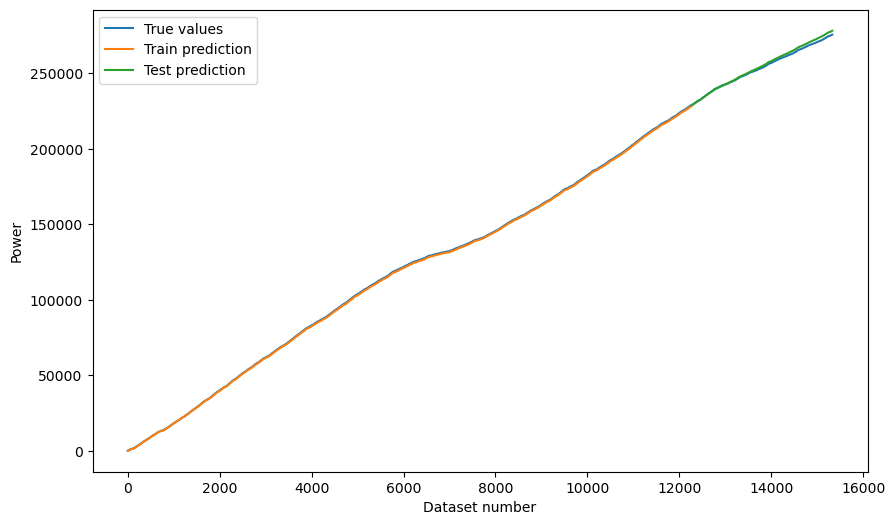

In [17]:
# Plotting for cumulative
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset).reshape(-1,1)
trainPredictPlot[:] = np.nan
trainPredictPlot[TIME_STEP:len(train_predict)+TIME_STEP] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset).reshape(-1,1)
testPredictPlot[:] = np.nan
testPredictPlot[
    len(train_predict) + (TIME_STEP * 2) + 1 : len(dataset) - 1
] = test_predict

true_values = np.cumsum((dataset).reshape(-1,1))
print(true_values.shape)
print(trainPredictPlot.shape)
# plot baseline and predictions
plt.clf()
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 10})
plt.xlabel("Dataset number")
plt.ylabel("Power")
plt.plot(true_values, label="True values")
# plt.plot(test_true.reshape(-1,1), label="Test true")
plt.plot(trainPredictPlot, label="Train prediction")
plt.plot(testPredictPlot, label="Test prediction")
leg = plt.legend()

plt.savefig(f"{MODEL_LOCATION}/{version}/predict_cumulative.png")
plt.show()